# Collider Ring Studies (twiss_ir1ccma_hybrid_v06).

In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint import beam_optics as bopt
from mint import const, xsecs
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create main collider-ring lattice

In [ ]:
twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"

ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
ring_lattice = lt.Lattice(**ring_dict)
ring_lattice.name = "twiss_ir1ccma_hybrid_v06"
ring_lattice.short_name = "ir1ccma_v06"

# Operation assumptions
ring_lattice.Nmu_per_bunch = 2e12
ring_lattice.finj = 5.0
ring_lattice.bunch_multiplicity = 1.0
ring_lattice.duty_factor = 1 / np.pi # 1e7 seconds per year

print(f"Lattice: {ring_lattice.name}")
print(f"Ring circumference: {ring_lattice.s(1)/1e3:.2f} km")

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x13f268370>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x13f26be30>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x13f26a3f0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x13f268730>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x13f2680a0>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x13f26ab20>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x13f268be0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x13f268dc0>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x13f269540>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x13f26a530>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

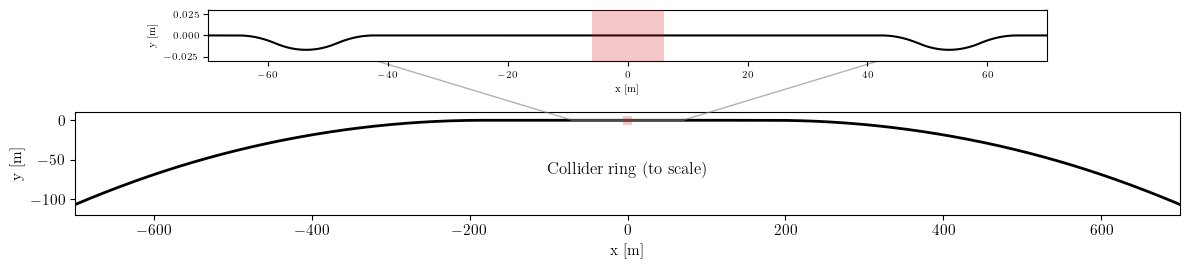

In [58]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0, color='black')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.text(0.5, 0.4, "Collider ring (to scale)", transform=ax.transAxes, ha="center", fontsize=12)
ax.set_xlim(-700, 700)
ax.set_ylim(-120, 10)
ax.set_aspect("equal", adjustable="box")

# Detector box: ±6 m around IP (0, 0)
det_half = 6  # meters
det_box = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                         linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
ax.add_patch(det_box)

# Inset: chicane detail at ~x=50m, y~20cm
xl = 0.12
axins = ax.inset_axes([xl, 1.5, (1 - 2*xl), 0.5])
axins.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=1.5, color='black')
axins.set_xlim(-70, 70)
axins.set_ylim(-0.03, 0.03)
axins.tick_params(labelsize=7)
axins.set_xlabel("x [m]", fontsize=7)
axins.set_ylabel("y [m]", fontsize=7)
ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.6)

# Detector box in inset
det_box_ins = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                              linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
axins.add_patch(det_box_ins)
# axins.set_aspect("equal", adjustable="box")

fig.tight_layout()
fig.savefig("plots/collider_ring_geometry.pdf", dpi=400)


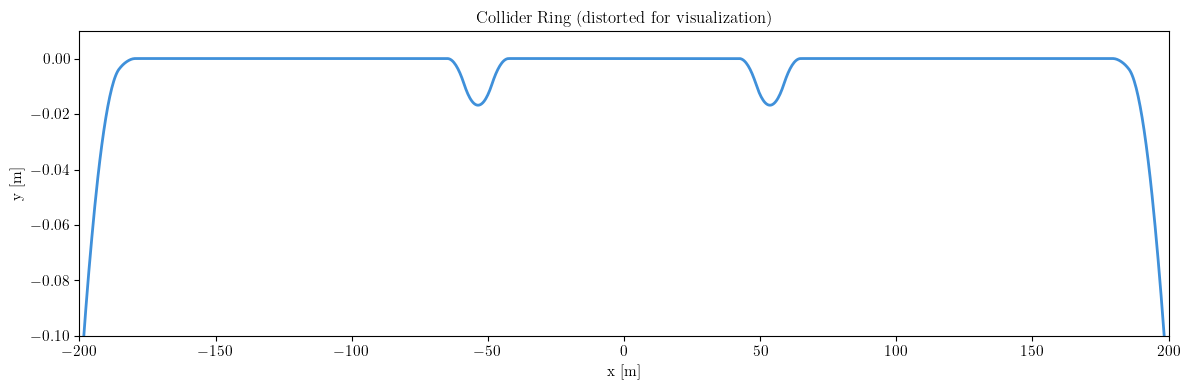

In [59]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider Ring (distorted for visualization)")
ax.set_ylim(-0.1,0.01)
ax.set_xlim(-200,200)
fig.tight_layout()

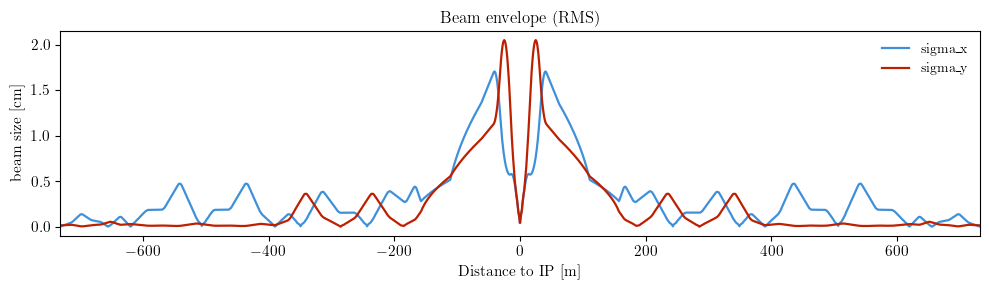

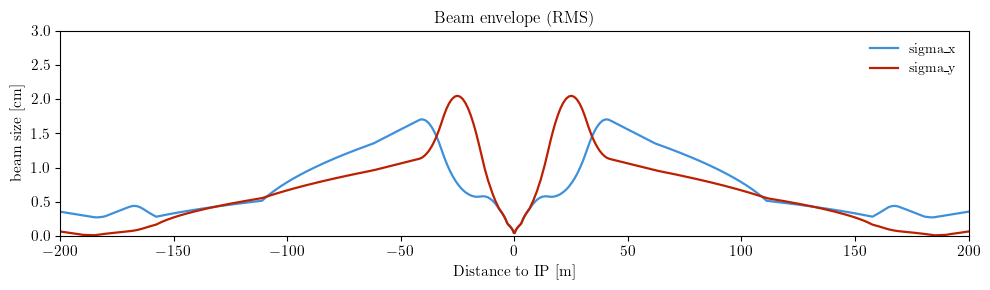

In [60]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope.pdf", dpi=300, bbox_inches="tight")



fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_ylim(1e-3*0, 3)
# ax_env.set_yscale('log')
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope_zoomed.pdf", dpi=300, bbox_inches="tight")


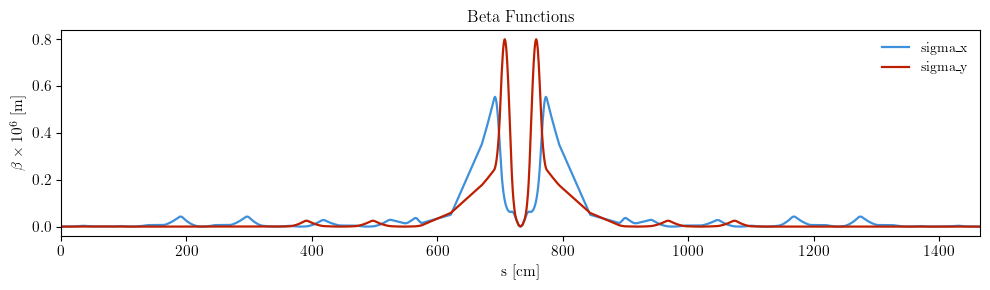

In [61]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
s_m = ring_lattice.s(u) * 1e-2
sigma_x = ring_dict["betx"](u) * 1e-6
sigma_y = ring_dict["bety"](u) * 1e-6

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel(r"s [cm]")
ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
ax_env.set_title("Beta Functions")
ax_env.legend(frameon=False)
ax_env.set_xlim(s_m.min(), s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beta_functions.pdf", dpi=300, bbox_inches="tight")


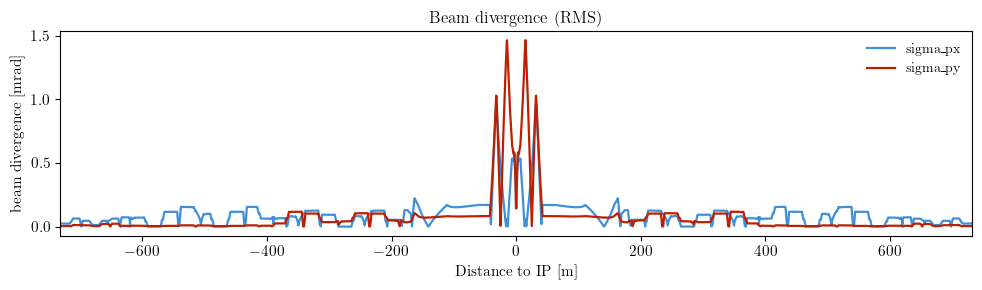

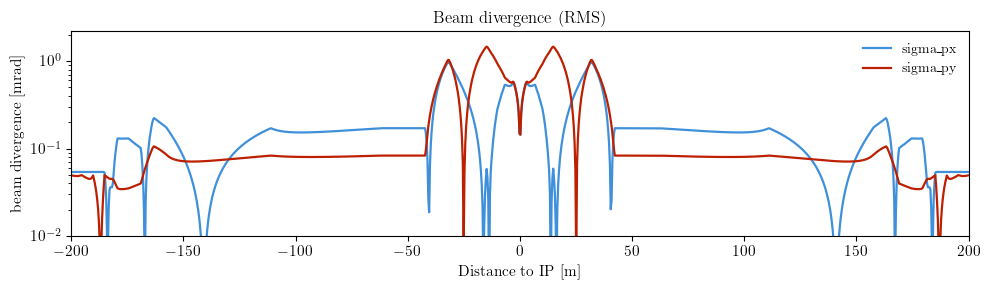

In [62]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence.pdf", dpi=300, bbox_inches="tight")

# ZOOMED IN
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_yscale('log')
ax_env.set_ylim(0.01, None)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence_zoomed.pdf", dpi=300, bbox_inches="tight")

## Simulate forward neutrino flux

In [63]:
n_evals = 1e6

ring_sims = {
    "numubar": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numubar_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
    "numu": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=True),
    "numu_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=False),
}

for flavor, sim in ring_sims.items():
    sim.decay_muons()

    if ring_sims[flavor]=="numu" or ring_sims[flavor]=="numu_nobd":
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="counter-clockwise")
    else:
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="clockwise")

In [64]:
# Detector and running assumptions for event-rate estimate
det_radius = 0.1e2  # cm (2 m radius)
detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00
nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, 1e5])  # 1 km downstream
det_location2 = np.array([0.0, 0.0, -1e5])  # 1 km upstream for mu- decay

bunches_per_year = (
    ring_lattice.finj
    * ring_lattice.bunch_multiplicity
    * ring_lattice.duty_factor
    * const.s_in_year
)


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/273792356.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


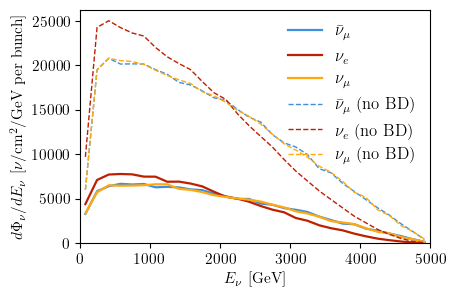

In [65]:
# Forward detector setup (on-axis, downstream)
energy_edges = np.linspace(0, 5e3, 31)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

flux_results = {}
for flavor, sim in ring_sims.items():
    if ring_sims[flavor] == "numu" or ring_sims[flavor] == "numu_nobd":
        loc = det_location2
    else:
        loc = det_location
    e_edges, flux = sim.get_flux_at_generic_location(
        det_location=loc,
        det_radius=det_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=1,
    )

    if np.isscalar(e_edges):
        flux = np.zeros_like(energy_centers)
    flux_results[flavor] = flux

fig, ax = pt.std_fig()
label = {"numubar": r"$\bar\nu_\mu$", "nue": r"$\nu_e$", "numu": r"$\nu_\mu$"}
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor], lw=1.6, label=label[flavor])
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

plt.gca().set_prop_cycle(None)
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor+'_nobd'], lw=1, ls='--', label=label[flavor]+r' (no BD)')
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

ax.set_xlim(0, 5e3)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$/cm$^{2}$/GeV per bunch]")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_flux_spectrum.pdf", dpi=300, bbox_inches="tight")

In [66]:
sim.weights, sim.pnu

(array([[ 1158.30767903],
        [ 3755.31942762],
        [  783.46594462],
        ...,
        [25677.03424135],
        [25562.99516251],
        [24808.47327283]]),
 MomentumNumpy4D([(-1.83527973e-06,  5.81495127e-03, 1.96140943e-02, 2.04579167e-02),
                  ( 4.34405158e-04,  2.14716063e-01, 9.59009303e-01, 9.82752267e-01),
                  ( 6.95201471e-06, -2.48664273e-05, 2.61610072e-02, 2.61610200e-02),
                  ...,
                  ( 3.77095323e-03, -1.83282941e+03, 4.63830981e+03, 4.98730203e+03),
                  ( 4.05612143e-03,  3.36971355e+02, 4.97070444e+03, 4.98211324e+03),
                  (-2.26064682e-03, -3.02515341e+02, 4.98390546e+03, 4.99307813e+03)],
                 dtype=[('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('t', '<f8')]))

In [267]:
def get_flux_at_annuli(sim,  flavor, det_loc=det_location, r_edges=np.linspace(0.0, det_radius, 51)):
    # compute and plot radial event-rate density dN/dr at 1 km (det_location already in cm)
    r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
    dr = np.diff(r_edges)  # cm

    cum_events_per_bunch = {fl: [] for fl in ring_sims}

    for r in r_edges:
        _, flux = sim.get_flux_at_generic_location(
            det_location=det_loc,        # center on axis
            det_radius=r,                     # disk radius in cm
            ebins=energy_edges,
            per_cm2=True,
            normalization=1,
        )
        if np.isscalar(_) or flux is None:
            flux = np.zeros_like(energy_centers)
        sigma = xsecs.total_xsecs[flavor](energy_centers)
        p_int = sigma * nucleon_column_density
        area_disk = np.pi * r**2  # cm^2
        events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk
        cum_events_per_bunch[flavor].append(events_per_bunch_disk)

    # convert cumulative lists -> arrays
    for fl in cum_events_per_bunch:
        cum_events_per_bunch[fl] = np.array(cum_events_per_bunch[fl])

    # annulus events per bunch and per year, convert to per meter (multiply by 100)
    dN_dr_per_year_per_m = {}
    annulus_events_per_bunch = np.diff(cum_events_per_bunch[flavor])         # events per bunch in annulus (per cm width = dr)
    dN_dr_per_year_per_cm = annulus_events_per_bunch / dr               # events per bunch per cm
    dN_dr_per_year_per_cm *= bunches_per_year                             # events per year per cm
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0            # events per year per m
    return dN_dr_per_year_per_m

In [272]:
r_edges = np.linspace(0.0, 50, 101)  # cm
dN_dr_per_year_per_m_numubar = get_flux_at_annuli(ring_sims["numubar"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue = get_flux_at_annuli(ring_sims["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numubar_noBD = get_flux_at_annuli(ring_sims["numubar_nobd"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD = get_flux_at_annuli(ring_sims["nue_nobd"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numu = get_flux_at_annuli(ring_sims["numu"], "numu",det_loc=det_location2, r_edges=r_edges)
dN_dr_per_year_per_m_numu_noBD = get_flux_at_annuli(ring_sims["numu_nobd"], "numu",det_loc=det_location2, r_edges=r_edges)


No flux through detector.


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/39915786.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk


No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux thro

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/2009336761.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


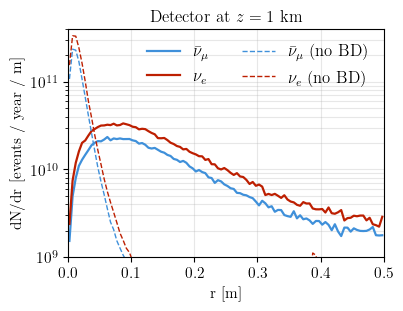

In [285]:
# plot
fig, ax = pt.std_fig(figsize=(4, 3))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar, lw=1.6, label=label["numubar"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue, lw=1.6, label=label["nue"])
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu, lw=1.6, label=label["numu"])

plt.gca().set_prop_cycle(None)

ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD, lw=1., ls='--', label=label["numubar"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD, lw=1., ls='--', label=label["nue"]+r' (no BD)')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu_noBD, lw=1., ls='--', label=label["numu"]+r' (no BD)')

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 0.5)
# ax.set_xscale
ax.grid(True, which='both', ls='-', alpha=0.3)
ax.set_ylim(1e9, 4e11)
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial.pdf", dpi=300, bbox_inches="tight")

## Estimate forward event rate

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/3253303844.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Estimated total forward event rate (numubar): 2.919e+09 events/year
Estimated total forward event rate (nue):  2.564e+09 events/year
Estimated total forward event rate (numu):  2.919e+09 events/year


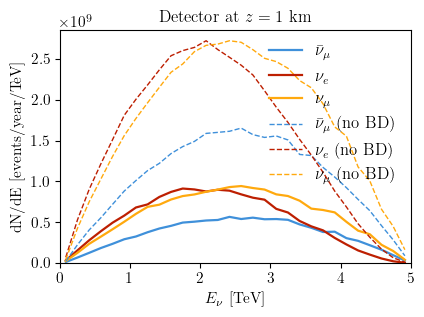

In [71]:
GeV_to_TeV = 1e-3
event_results = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }


for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor+'_nobd'] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor+'_nobd'] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

fig, ax = pt.std_fig()
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor]["dN_dE_per_year"]/GeV_to_TeV, lw=1.6, label=label[flavor])
plt.gca().set_prop_cycle(None)
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor+"_nobd"]["dN_dE_per_year"]/GeV_to_TeV, lw=1., ls='--', label=label[flavor]+r' (no BD)')
    # ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()

tot_numu = np.trapezoid(event_results["numubar"]["dN_dE_per_year"], energy_centers)
tot_nue = np.trapezoid(event_results["nue"]["dN_dE_per_year"], energy_centers)
tot_numu = np.trapezoid(event_results["numu"]["dN_dE_per_year"], energy_centers)

print(f"Estimated total forward event rate (numubar): {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nue):  {tot_nue:.3e} events/year")
print(f"Estimated total forward event rate (numu):  {tot_numu:.3e} events/year")

fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")

## Compare Event Rates with Previous Neutrino Experiments

In [243]:
def get_event_rate(det_length, det_radius_cm, e_edges=None, L_to_IP_cm=1e5, rho_g_cm3=1.0):
    # Detector and running assumptions for event-rate estimate
    detector_area_cm2 = np.pi * det_radius_cm**2
    
    # det_mass = detector_area_cm2 * detector_length_cm * rho_g_cm3
    # det_column_density_nucleon_cm2 = detector_length_cm * rho_g_cm3 / const.m_proton_in_g
    det_mass = detector_area_cm2 * det_length * rho_g_cm3
    det_column_density_nucleon_cm2 = det_mass / const.m_proton_in_g / detector_area_cm2
    
    print("L for 1 g/cm^3:", det_column_density_nucleon_cm2 * const.m_proton_in_g)

    bunches_per_year = (
        ring_lattice.finj
        * ring_lattice.bunch_multiplicity
        * ring_lattice.duty_factor
        * const.s_in_year
    )

    if e_edges is None:
        energy_edges = np.linspace(0, 5e3, 31)
    else:
        energy_edges = e_edges
    
    energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

    flux_results = {}
    for flavor, sim in ring_sims.items():
        
        if ring_sims[flavor] == "numu" or ring_sims[flavor] == "numu_nobd":
            loc = np.array([0.0, 0.0, -L_to_IP_cm])  # 1 km upstream for mu- decay
        else:
            loc = np.array([0.0, 0.0, L_to_IP_cm])  # 1 km downstream

        e_edges, flux = sim.get_flux_at_generic_location(
            det_location=loc,
            det_radius=det_radius_cm,
            ebins=energy_edges,
            per_cm2=True,
            normalization=1,
        )

        if np.isscalar(e_edges):
            flux = np.zeros_like(energy_centers)
        flux_results[flavor] = flux


    event_results = {}
    for flavor in ["numubar", "nue", "numu"]:

        sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
        p_int = sigma_tot * det_column_density_nucleon_cm2
        print("Interaction probability for", flavor, ":", np.max(p_int))

        # Here we multiply back by the det area.
        dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

        # dN/dE per year
        dN_dE_per_year = dN_dE_per_decay * bunches_per_year

        event_results[flavor] = {
            "dN_dE_per_decay": dN_dE_per_decay,
            "dN_dE_per_year": dN_dE_per_year,
        }
        # -----------------
        # No beam dynamics case
        
        # Here we multiply back by the det area.
        dN_dE_per_decay = flux_results[flavor+"_nobd"] * detector_area_cm2 * p_int

        # dN/dE per year
        dN_dE_per_year = dN_dE_per_decay * bunches_per_year

        event_results[flavor+"_nobd"] = {
            "dN_dE_per_decay": dN_dE_per_decay,
            "dN_dE_per_year": dN_dE_per_year,
        }
    return event_results

In [286]:
r_vals = np.geomspace(0.1, 2e2, 50)
n_total_numubar = []
n_total_numubar_noBD = []
n_total_nue = []
n_total_nue_noBD = []
for r in r_vals:
    event_results_r = get_event_rate(det_length=10e2, det_radius_cm=r, L_to_IP_cm=L_det)
    n_total_numubar.append(np.trapz(event_results_r["numubar"]["dN_dE_per_year"], energy_centers))
    n_total_nue.append(np.trapz(event_results_r["nue"]["dN_dE_per_year"], energy_centers))
    event_results_r = get_event_rate(det_length=10e2, det_radius_cm=r, L_to_IP_cm=L_det)
    n_total_numubar_noBD.append(np.trapz(event_results_r["numubar_nobd"]["dN_dE_per_year"], energy_centers))
    n_total_nue_noBD.append(np.trapz(event_results_r["nue_nobd"]["dN_dE_per_year"], energy_centers))


L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/1846444486.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_total_numubar.append(np.trapz(event_results_r["numubar"]["dN_dE_per_year"], energy_centers))
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/1846444486.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_total_nue.append(np.trapz(event_results_r["nue"]["dN_dE_per_year"], energy_centers))


Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 999.9999999999999


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/1846444486.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_total_numubar_noBD.append(np.trapz(event_results_r["numubar_nobd"]["dN_dE_per_year"], energy_centers))
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/1846444486.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_total_nue_noBD.append(np.trapz(event_results_r["nue_nobd"]["dN_dE_per_year"], energy_centers))


Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.278593113009287e-08
L for 1 g/cm^3: 999.9999999999999
Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.278593113009287e-08
L for 1 g/cm^3: 999.9999999999999
Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.278593113009287e-08
L for 1 g/cm^3: 999.9999999999999
Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.278593113009287e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L f

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/816879165.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


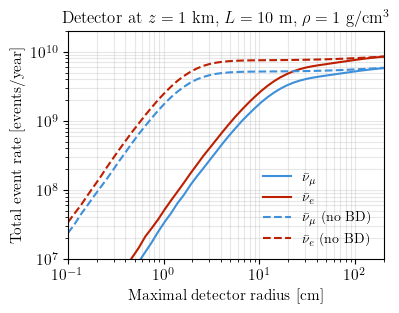

In [288]:
fig, ax = pt.std_fig(figsize=(4, 3))

ax.plot(r_vals, n_total_numubar, label=r"$\bar{\nu}_\mu$", )
ax.plot(r_vals, n_total_nue, label=r"$\bar{\nu}_e$")

plt.gca().set_prop_cycle(None)

ax.plot(r_vals, n_total_numubar_noBD, label=r"$\bar{\nu}_\mu$ (no BD)", ls='--')
ax.plot(r_vals, n_total_nue_noBD, label=r"$\bar{\nu}_e$ (no BD)", ls='--')

ax.legend(frameon=False, fontsize=10, loc="lower right")
ax.grid(True, which="both", ls="-", alpha=0.3)

ax.set_xlim(0.1, 2e2)
ax.set_ylim(1e7, 2e10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Maximal detector radius [cm]")
ax.set_ylabel("Total event rate [events/year]")
ax.set_title(r"Detector at $z = 1$ km, $L = 10$~m, $\rho = 1$ g/cm$^3$")


fig.tight_layout()
fig.savefig("plots/total_event_rate_vs_radius.pdf", dpi=300, bbox_inches="tight")

In [82]:
# pull data of neutrino experiments
import os
import csv
nu_spectrum_dir = "nu_spectrum_data"
nu_spectrum_arrays = {}
for fname in os.listdir(nu_spectrum_dir):
    if fname.endswith(".csv"):
        arr = []
        with open(os.path.join(nu_spectrum_dir, fname), "r") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) >= 2:
                    try:
                        x = float(row[0])
                        y = float(row[1])
                        arr.append((x, y))
                    except ValueError:
                        continue
        key = fname.replace(".csv", "").replace("_", " ")
        nu_spectrum_arrays[key] = arr
# Example: chorus = nu_spectrum_arrays["chorus"]
for key, arr in nu_spectrum_arrays.items():
    globals()[key] = arr

In [95]:
nu_spectrum_arrays.keys()

dict_keys(['NOMAD', 'MuC 10TeV', 'CDHS', 'FPF', 'NuTeV', 'DUNE ND', 'CHORUS', 'FASER'])

## MuC comparison 

In [305]:
L_det = 1e5  # cm (1 km)
event_results = get_event_rate(det_length=10e2, det_radius_cm=1e2, L_to_IP_cm=L_det)
event_results_2 = get_event_rate(det_length=10e2, det_radius_cm=2e2, L_to_IP_cm=L_det)
event_results_3 = get_event_rate(det_length=10e2, det_radius_cm=2e2, L_to_IP_cm=L_det)

L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08


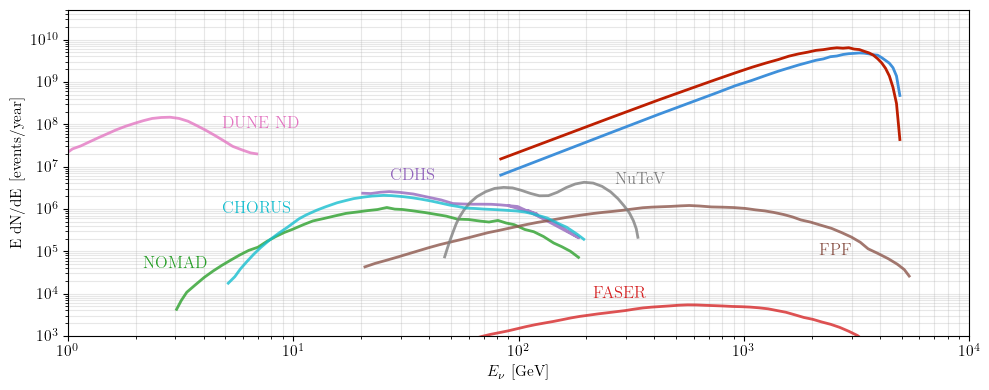

In [ ]:
# fig, ax = pt.std_fig()

fig, ax = plt.subplots(figsize=(10, 4))
line_handles = []

line, = ax.plot(energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["numubar"]+" (Latest Design)")
line, = ax.plot(energy_centers, event_results["nue"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["nue"]+" (Latest Design)")
line_handles.append(line)
ax.set_xscale("log")
ax.set_yscale("log")

# Plot the sum of numubar and numu for the latest design
# sum_event = event_results["numubar"]["dN_dE_per_year"] * energy_centers + event_results["numu"]["dN_dE_per_year"] * energy_centers
# sum_line, = ax.plot(energy_centers, sum_event, lw=2, label=r"$\bar\nu_\mu + \nu_\mu$ (Latest Design)", color="black")
# ax.set_xscale("log")
# ax.set_yscale("log")

plt.gca().set_prop_cycle(None)

# Plot neutrino experiment data as lines
experiment_colors = ["tab:green", "grey", "tab:purple", "tab:brown", "tab:gray", "tab:pink", "tab:cyan", "tab:red"]
exp_line_handles = []
for i, (exp_name, arr) in enumerate(nu_spectrum_arrays.items()):
    arr = np.array(arr)
    if arr.shape[1] == 2:
        if exp_name in ["MuC 10TeV"]:
            ls = (1,(3,1))
            continue
        else:
            ls = '-'
        exp_line, = ax.plot(arr[:,0], arr[:,1], linestyle=ls, label=exp_name, lw=2, color=experiment_colors[i % len(experiment_colors)], alpha=0.8)
        exp_line_handles.append((exp_line, exp_name))

ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"E dN/dE [events/year]")
ax.set_xlim(1, 1e4)
ax.set_ylim(1e3, 5e10)
# Remove the default legend
# ax.legend(frameon=False, fontsize=12)
# ax.set_title(r"Neutrino Spectrum for a Detector at $z = 1$ km")
fig.tight_layout()

# Annotate each line with its label and color
# Now allow manual adjustment of label positions
# Provide a dictionary for manual label positions: {label: (x, y)}
manual_label_positions = {
    # Example: 'label_text': (x_value, y_value)
    # You can fill these in manually for each line
    r"$\bar\nu_\mu$ MuC 10 TeV": (110, 6e8),
    r"$\nu_e$ MuC 10 TeV": (70, 1e8),
    r"MuC 10TeV": (1000, 1.5e8),
    r"CHORUS": (4.5, 1e6),
    r"DUNE ND": (4.5, 1e8),
    r"NuTeV": (250, 5e6),
    r"FPF": (2000, 1e5),
    r"NOMAD": (2,5e4),
    r"CDHS": (25,6e6),
    r"FASER": (200, 1e4),
    r"$\nu_\mu$ MuC 10 TeV": (300, 2e9),
    "Latest Design": (270, 2e9)
}

def annotate_line(ax, line, label, xdata, ydata):
    if label in manual_label_positions:
        x_pos, y_pos = manual_label_positions[label]
    else:
        # Default: 70% along the line
        x_pos = xdata[0]
        y_pos = np.max(ydata) * 1.9
    ax.annotate(label,
                xy=(x_pos, y_pos),
                xytext=(5, 0),
                textcoords='offset points',
                color=line.get_color(),
                fontsize=12,
                va='center',
                ha='left',
                fontweight='bold')

# Annotate main design lines
# annotate_line(ax, line_handles[0], r"\noindent MuC 10 TeV "+label["numubar"]+r" \\($z=1$~km, $L=10$~m, $r=10$ cm, $10^3$ cycles)", energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers)
# annotate_line(ax, line_handles[1], r"\noindent MuC 10 TeV "+label["nue"]+r" \\($z=1$~km, $L=10$~m, $r=10$ cm, $10^3$ cycles)", energy_centers, event_results["nue"]["dN_dE_per_year"]*energy_centers)

# annotate_line(ax, sum_line, "Latest Design", energy_centers, sum_event)
ax.grid(True, which='both', ls='-', alpha=0.3)
# Annotate experiment lines
for exp_line, exp_name in exp_line_handles:
    xdata = exp_line.get_xdata()
    ydata = exp_line.get_ydata()
    # Only annotate if there is data
    if len(xdata) > 0 and len(ydata) > 0:
        annotate_line(ax, exp_line, exp_name, xdata, ydata)

fig.savefig("plots/numubar_spectrum.pdf", dpi=300, bbox_inches="tight")


# Energy spectrum (PRISM)

In [ ]:
radii_cm = np.linspace(0.1, 2e2, 10)  # cm
energy_spectra = []
for r_cm in radii_cm:
    energy_spectra.append(get_event_rate(det_length=10e2, det_radius_cm=r_cm, L_to_IP_cm=1e5))

L for 1 g/cm^3: 1000.0000000000001
Interaction probability for numubar : 1.4372175602969257e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4372175602969255e-08
Interaction probability for nue : 2.2785931130092873e-08
Interaction probability for numu : 2.2785931130092873e-08
L for 1 g/cm^3: 999.9999999999999
Interaction probability for numubar : 1.4372175602969253e-08
Interaction probability for nue : 2.278593113009287e-08
Interaction probability for numu : 2.2785

In [246]:
# Energy spectrum of numubar for 19 radial annuli with 1 cm gaps (0–19 cm)
r_edges_cm = np.linspace(0, 5, 10)  # 20 edges → 19 annuli: [0-1], [1-2], ..., [18-19] cm
e_vals = np.linspace(0, 5e3, 51)  # GeV

er_edges = []
for r_cm in r_edges_cm:
    if r_cm == 0:
        er_edges.append(None)
    else:
        er_edges.append(get_event_rate(det_length=10e2, det_radius_cm=r_cm, L_to_IP_cm=1e5, e_edges=e_vals))


L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0000000000001
Interaction probability for numubar : 1.4467624835009945e-08
Interaction probability for nue : 2.2928582863051682e-08
Interaction probability for numu : 2.2928582863051682e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L for 1 g/cm^3: 1000.0
Interaction probability for numubar : 1.4467624835009943e-08
Interaction probability for nue : 2.292858286305168e-08
Interaction probability for numu : 2.292858286305168e-08
L

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_24277/171939074.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


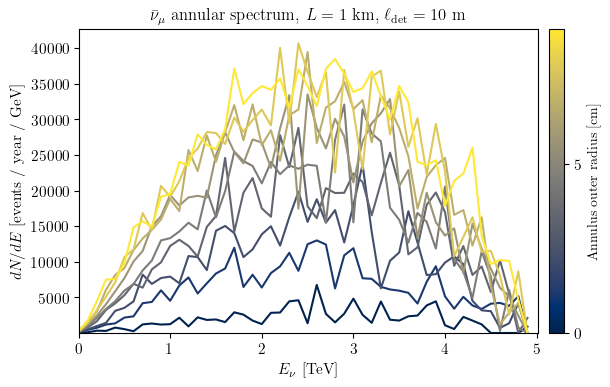

In [250]:
n_annuli = len(r_edges_cm) - 1  # 19
cmap = plt.cm.cividis
colors = [cmap(i / (n_annuli - 1)) for i in range(n_annuli)]

fig, ax = pt.std_fig(figsize=(7, 4))

for i in range(n_annuli):
    spec_outer = er_edges[i + 1]["numubar"]["dN_dE_per_year"]
    spec_inner = np.zeros_like(spec_outer) if er_edges[i] is None else er_edges[i]["numubar"]["dN_dE_per_year"]
    annulus_spec = spec_outer - spec_inner
    ax.plot(e_vals[:-1] * 1e-3, annulus_spec, lw=1.5, color=colors[i])

# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlim(0, 5.01)
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"$dN/dE$ [events / year / GeV]")
ax.set_ylim(bottom=1)
ax.set_title(r"$\bar\nu_\mu$ annular spectrum, $L = 1$ km, $\ell_\mathrm{det} = 10$ m")

# Colorbar to indicate annulus radius
import matplotlib.colors as mcolors
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=n_annuli))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"Annulus outer radius [cm]", fontsize=10)
cbar.set_ticks(np.arange(0, n_annuli + 1, 5))

fig.tight_layout()
fig.savefig("plots/numubar_spectrum_annuli.pdf", dpi=300, bbox_inches="tight")
